# Data Understanding

### 1. Import Library

Pertama-tama yang dibutuhkan adalah beberapa library utama yaitu ada pandas yang digunakan untuk memanipulasi data, numpy untuk mengoperasi numerik, matplomatplotlib.pyplot & seaborn digunakan untuk visualisasi, dan scikit-learn biasanya adalah opsional, atau bisa digunakan untuk preprocessing & split data.




In [1]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

### 2. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("data-iris.csv")

In [4]:
print("\n--- Ukuran Data ---")
print("="*45)
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


--- Ukuran Data ---
Ukuran dataset: 150 baris, 6 kolom


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0


### 3. Struktur Dataset

In [5]:
print("\n--- Tipe Data ---")
print("="*45)
print(df.info())
print("\n--- 5 Data Teratas ---")
display(df.head())



--- Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
 5   vnum          150 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

--- 5 Data Teratas ---


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0


In [7]:
print("\n--- Cek Nilai Unik Di Kolom Target ---")
print("="*45)
print(df["variety"].value_counts())


--- Cek Nilai Unik Di Kolom Target ---
variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### 4. Tipe Data

In [8]:
print("\n--- Tipe Data Kolom ---")
print("="*45)
print(df.dtypes)


--- Tipe Data Kolom ---
sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
vnum              int64
dtype: object


### 5. Mengecek Missing Value dan Duplikasi

In [10]:
print("\n--- Missing Value ---")
print("="*45)
print(df.isnull().sum())


--- Missing Value ---
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
vnum            0
dtype: int64


In [11]:
print("\n--- Jumlah Duplikasi ---")
print("="*45)
print("Jumlah duplikasi:", df.duplicated().sum())


--- Jumlah Duplikasi ---
Jumlah duplikasi: 1


### 6. Eksplorasi Data Awal


--- Deskripsi Statistik ---


,sepal.length,sepal.width,petal.length,petal.width,vnum
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


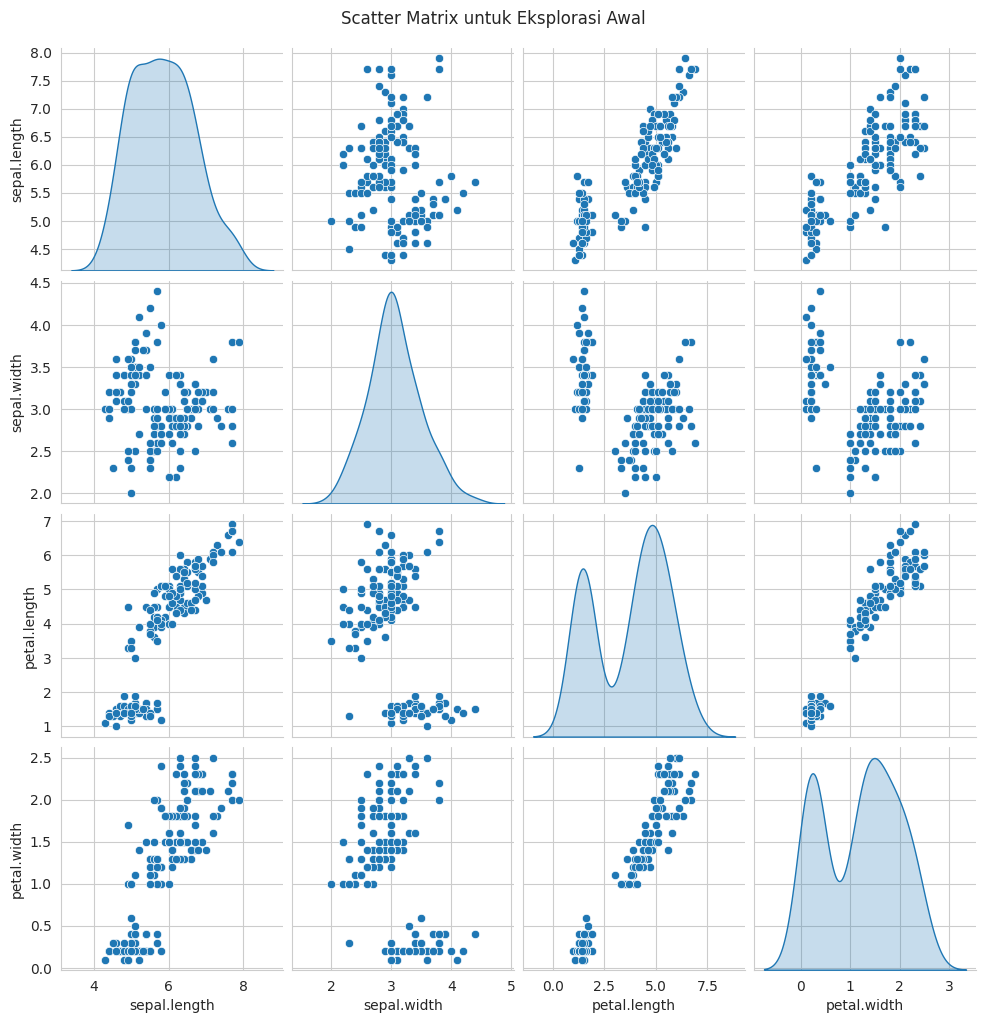

In [12]:
print("\n--- Deskripsi Statistik ---")
display(df.describe().round(2))

# Visualisasi matriks scatter menggunakan seaborn
sns.set_style("whitegrid")
pairplot = sns.pairplot(df.drop(["vnum", "variety"], axis=1), diag_kind="kde")
pairplot.fig.suptitle("Scatter Matrix untuk Eksplorasi Awal", y=1.02)
plt.show()

### 7. Analisis Distribusi Data Per Fitur


=== Histogram Distribusi Setiap Fitur ===


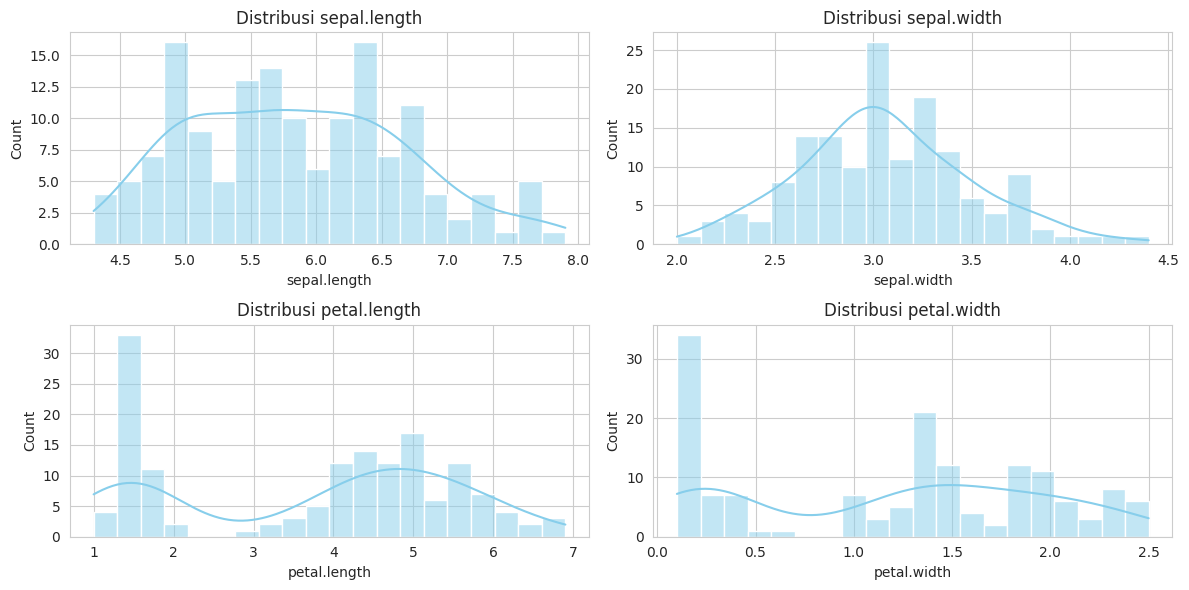

In [13]:
print("\n=== Histogram Distribusi Setiap Fitur ===")
plt.figure(figsize=(12,6))
num_cols = df.columns[:-2]  # hanya fitur numerik
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20, color="skyblue")
    plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

### 8. Pairplot sebaran per spesies


=== Pairplot Sebaran Data per Spesies ===


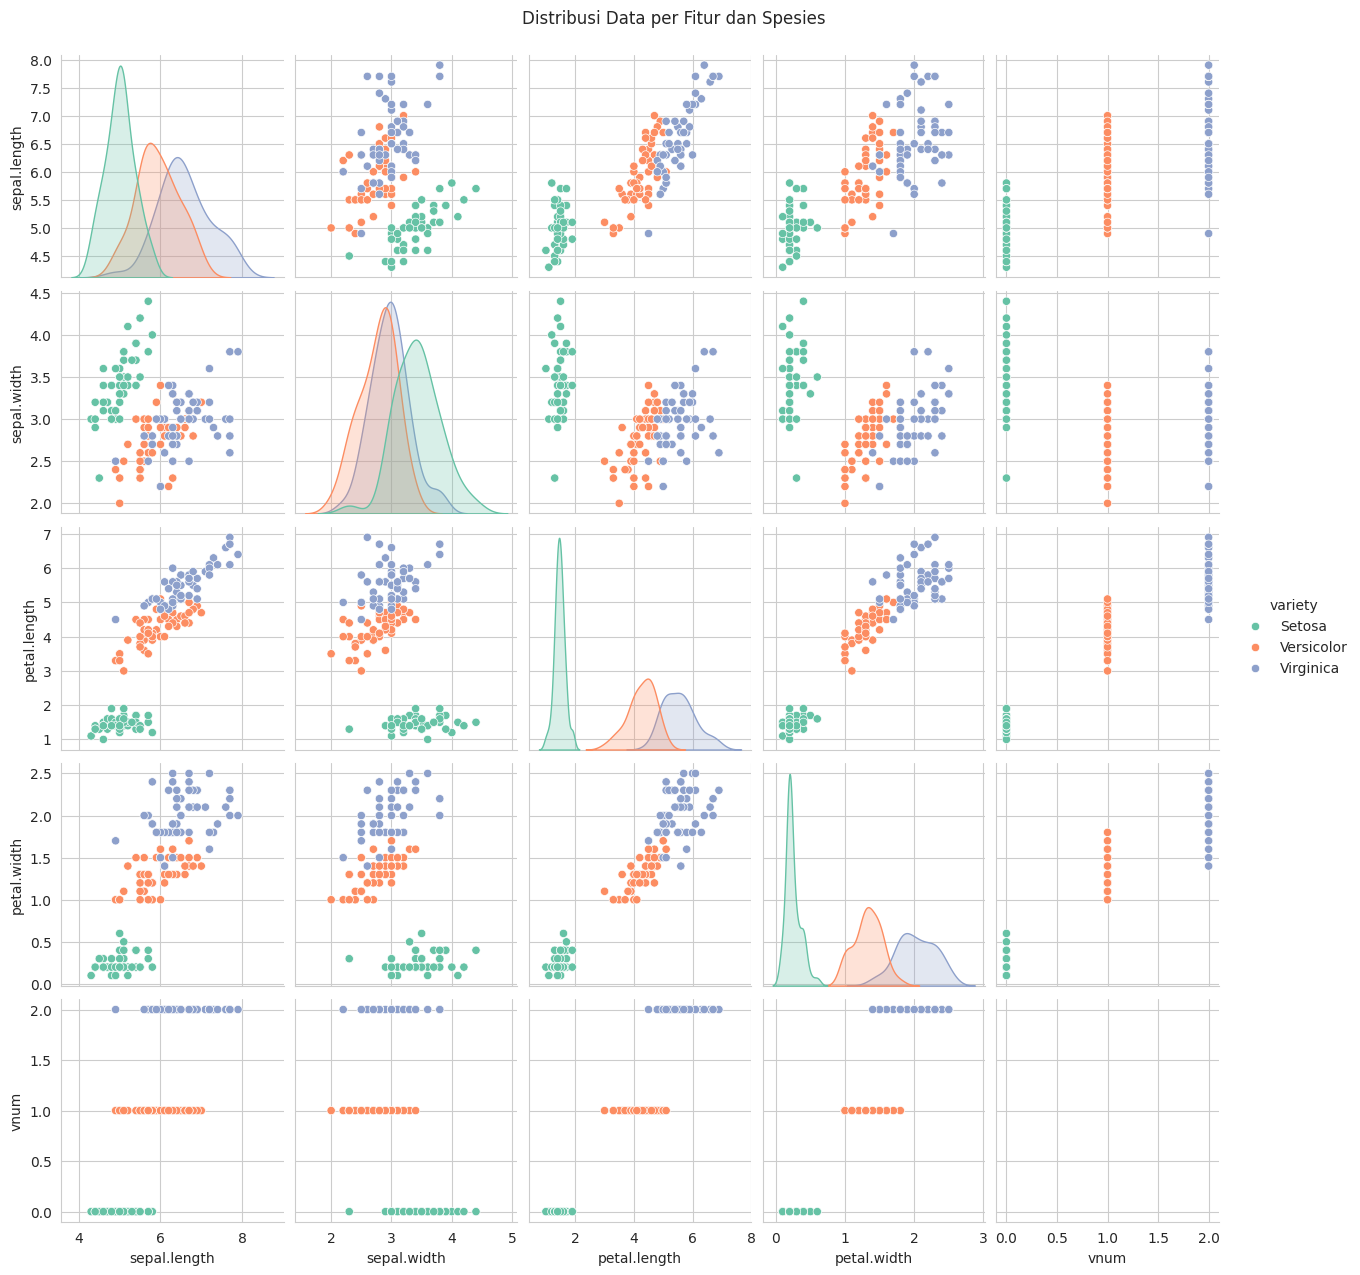

In [14]:
print("\n=== Pairplot Sebaran Data per Spesies ===")
pairplot_fig = sns.pairplot(df, hue="variety", palette="Set2")
pairplot_fig.fig.suptitle("Distribusi Data per Fitur dan Spesies", y=1.02)
plt.show()

### 9. Korelasi Antar Fitur


=== Tabel Korelasi Fitur Numerik ===


,sepal.length,sepal.width,petal.length,petal.width,vnum
sepal.length,1.000000,-0.117570,0.871754,0.817941,0.782561
sepal.width,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal.length,0.871754,-0.428440,1.000000,0.962865,0.949035
petal.width,0.817941,-0.366126,0.962865,1.000000,0.956547
vnum,0.782561,-0.426658,0.949035,0.956547,1.000000


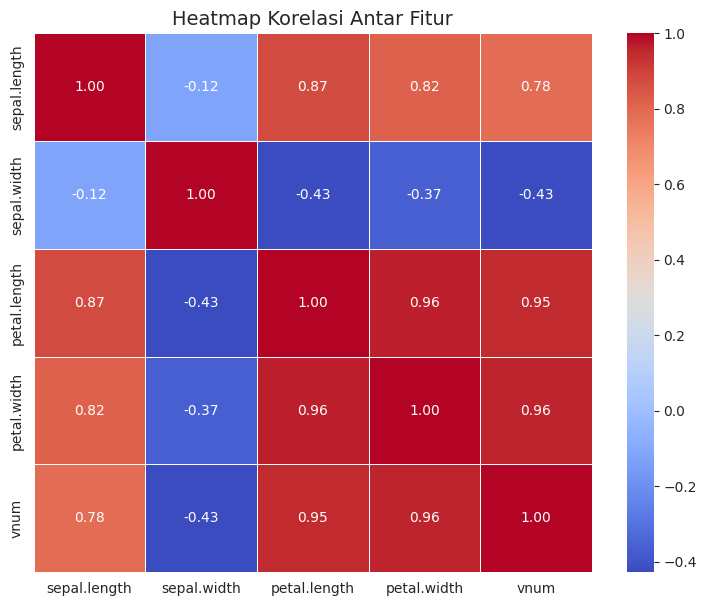

In [15]:
# Hitung matriks korelasi langsung (numeric_only=True)
korelasi = df.corr(numeric_only=True)

print("\n=== Tabel Korelasi Fitur Numerik ===")
display(korelasi)

# Visualisasi heatmap korelasi
plt.figure(figsize=(9,7))
sns.heatmap(korelasi, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur", fontsize=14)
plt.show()


### 10. Analisis Distribusi Fitur per Spesies


=== Analisis Distribusi Fitur per Spesies ===


/tmp/ipykernel_4577/3220724123.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(kelompok, patch_artist=True, labels=df['variety'].unique())
/tmp/ipykernel_4577/3220724123.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(kelompok, patch_artist=True, labels=df['variety'].unique())
/tmp/ipykernel_4577/3220724123.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(kelompok, patch_artist=True, labels=df['variety'].unique())
/tmp/ipykernel_4577/3220724123.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matp

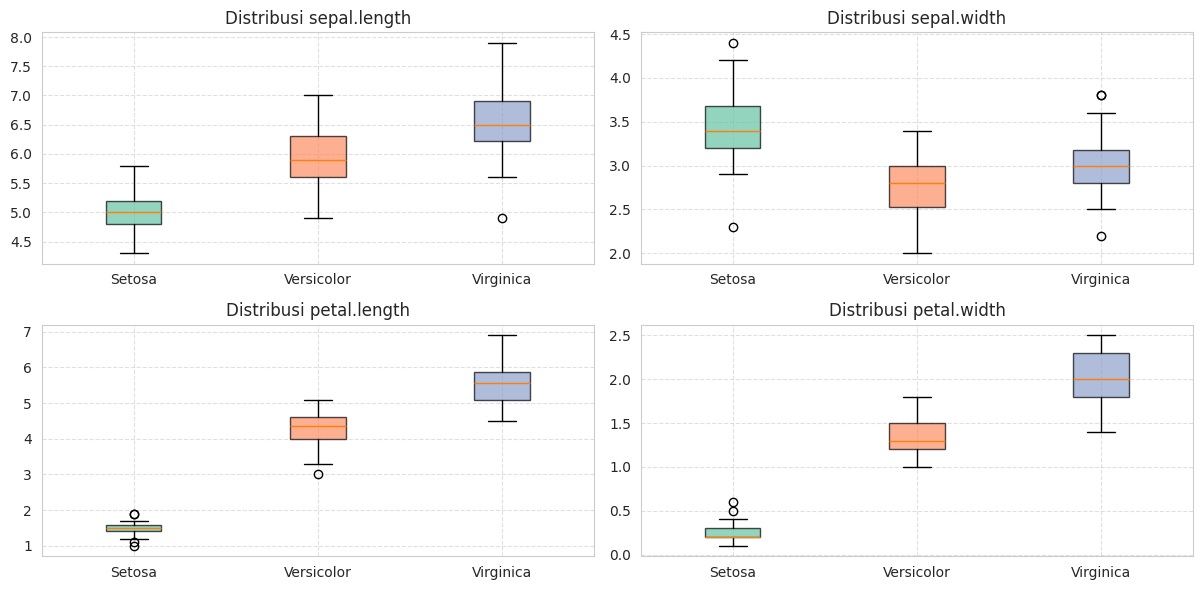

In [16]:
print("\n=== Analisis Distribusi Fitur per Spesies ===")

# Ambil hanya 4 kolom numerik pertama
feature_cols = df.select_dtypes(include='number').columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Warna dari seaborn palette
colors = sns.color_palette("Set2", 3)

for ax, col in zip(axes.ravel(), feature_cols):
    # Ambil data tiap spesies
    kelompok = [df.loc[df['variety'] == s, col] for s in df['variety'].unique()]

    # Buat boxplot dengan label langsung
    bp = ax.boxplot(kelompok, patch_artist=True, labels=df['variety'].unique())

    # Warnai boxplot
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    ax.set_title(f"Distribusi {col}")
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


### 11. Identifikasi Outlier (IQR per kolom + Z-Score & IQR keseluruhan)

In [18]:
from scipy import stats
import numpy as np
import pandas as pd

# --- Ambil hanya kolom numerik ---
kolom_num = df.select_dtypes(np.number)

# ============================================================
# 1. OUTLIER MENGGUNAKAN IQR (PER KOLOM)
# ============================================================
q_stats = kolom_num.quantile([0.25, 0.75])
iqr = q_stats.loc[0.75] - q_stats.loc[0.25]

mask_outlier_iqr = (
    kolom_num.lt(q_stats.loc[0.25] - 1.5 * iqr) |
    kolom_num.gt(q_stats.loc[0.75] + 1.5 * iqr)
)

print("\n=== [IQR] Jumlah Outlier per Kolom ===")
print(mask_outlier_iqr.sum().to_string())

persentase_iqr = (mask_outlier_iqr.sum() / len(df) * 100).round(2).astype(str) + " %"
print("\n=== [IQR] Persentase Outlier per Kolom ===")
print(persentase_iqr.to_string())

outliers_iqr = mask_outlier_iqr.any(axis=1)
print(f"\n>>> Total Outlier (IQR - baris): {outliers_iqr.sum()} sampel "
      f"({(outliers_iqr.sum()/len(df)*100):.2f}%)")


# ============================================================
# 2. OUTLIER MENGGUNAKAN Z-SCORE (PER KOLOM)
# ============================================================
z_scores = np.abs(stats.zscore(kolom_num, nan_policy='omit'))
mask_outlier_z = (z_scores > 3)

# Convert array → Series agar bisa .to_string()
jumlah_outlier_z = pd.Series(mask_outlier_z.sum(axis=0), index=kolom_num.columns)

print("\n=== [Z-Score] Jumlah Outlier per Kolom ===")
print(jumlah_outlier_z.to_string())

persentase_z = (jumlah_outlier_z / len(df) * 100).round(2).astype(str) + " %"
print("\n=== [Z-Score] Persentase Outlier per Kolom ===")
print(persentase_z.to_string())

outliers_z = jumlah_outlier_z.astype(bool)
outliers_z = mask_outlier_z.any(axis=1)

print(f"\n>>> Total Outlier (Z-Score - baris): {outliers_z.sum()} sampel "
      f"({(outliers_z.sum()/len(df)*100):.2f}%)")


# ============================================================
# 3. DATA OUTLIER (GABUNGAN Z-SCORE & IQR)
# ============================================================
df_outliers = df[outliers_z | outliers_iqr]

print("\n=== Data Outlier (contoh 5 baris) ===")
display(df_outliers.head())



=== [IQR] Jumlah Outlier per Kolom ===
sepal.length    0
sepal.width     4
petal.length    0
petal.width     0
vnum            0

=== [IQR] Persentase Outlier per Kolom ===
sepal.length     0.0 %
sepal.width     2.67 %
petal.length     0.0 %
petal.width      0.0 %
vnum             0.0 %

>>> Total Outlier (IQR - baris): 4 sampel (2.67%)

=== [Z-Score] Jumlah Outlier per Kolom ===
sepal.length    0
sepal.width     1
petal.length    0
petal.width     0
vnum            0

=== [Z-Score] Persentase Outlier per Kolom ===
sepal.length     0.0 %
sepal.width     0.67 %
petal.length     0.0 %
petal.width      0.0 %
vnum             0.0 %

>>> Total Outlier (Z-Score - baris): 1 sampel (0.67%)

=== Data Outlier (contoh 5 baris) ===


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
15,5.7,4.4,1.5,0.4,Setosa,0
32,5.2,4.1,1.5,0.1,Setosa,0
33,5.5,4.2,1.4,0.2,Setosa,0
60,5.0,2.0,3.5,1.0,Versicolor,1


### 12. Deteksi Outlier Per Kolom

In [19]:
from scipy import stats

print("\n=== Outlier Detail per Fitur (IQR & Z-Score) ===")

for col in kolom_num.columns:
    # === Metode IQR ===
    q1, q3 = kolom_num[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    outlier_iqr = df[(df[col] < batas_bawah) | (df[col] > batas_atas)][[col, "variety"]]

    print(f"\n>>> Outlier pada fitur '{col}' (IQR):")
    if not outlier_iqr.empty:
        display(outlier_iqr)
    else:
        print("Tidak ada outlier (IQR)")

    # === Metode Z-Score ===
    zscore_col = stats.zscore(kolom_num[col])
    outlier_z = df[np.abs(zscore_col) > 3][[col, "variety"]]

    print(f"\n>>> Outlier pada fitur '{col}' (Z-Score):")
    if not outlier_z.empty:
        display(outlier_z)
    else:
        print("Tidak ada outlier (Z-Score)")



=== Outlier Detail per Fitur (IQR & Z-Score) ===

>>> Outlier pada fitur 'sepal.length' (IQR):
Tidak ada outlier (IQR)

>>> Outlier pada fitur 'sepal.length' (Z-Score):
Tidak ada outlier (Z-Score)

>>> Outlier pada fitur 'sepal.width' (IQR):


,sepal.width,variety
15,4.4,Setosa
32,4.1,Setosa
33,4.2,Setosa
60,2.0,Versicolor



>>> Outlier pada fitur 'sepal.width' (Z-Score):


,sepal.width,variety
15,4.4,Setosa



>>> Outlier pada fitur 'petal.length' (IQR):
Tidak ada outlier (IQR)

>>> Outlier pada fitur 'petal.length' (Z-Score):
Tidak ada outlier (Z-Score)

>>> Outlier pada fitur 'petal.width' (IQR):
Tidak ada outlier (IQR)

>>> Outlier pada fitur 'petal.width' (Z-Score):
Tidak ada outlier (Z-Score)

>>> Outlier pada fitur 'vnum' (IQR):
Tidak ada outlier (IQR)

>>> Outlier pada fitur 'vnum' (Z-Score):
Tidak ada outlier (Z-Score)


### 12.1 Deteksi Outlier dengan Model ABOD, KNN, LOF

In [23]:
import numpy as np
import pandas as pd
from scipy import stats
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.abod import ABOD

# ============================================================
# 1. AMBIL FITUR NUMERIK
# ============================================================
X = df.select_dtypes(include="number")  # ambil hanya kolom numerik

# ============================================================
# 2. OUTLIER MENGGUNAKAN IQR (PER KOLOM)
# ============================================================
q_stats = X.quantile([0.25, 0.75])
iqr = q_stats.loc[0.75] - q_stats.loc[0.25]

mask_outlier_iqr = (
    X.lt(q_stats.loc[0.25] - 1.5 * iqr) |
    X.gt(q_stats.loc[0.75] + 1.5 * iqr)
)

print("\n=== [IQR] Jumlah Outlier per Kolom ===")
print(mask_outlier_iqr.sum().to_string())

persentase_iqr = (mask_outlier_iqr.sum() / len(df) * 100).round(2).astype(str) + " %"
print("\n=== [IQR] Persentase Outlier per Kolom ===")
print(persentase_iqr.to_string())

outliers_iqr = mask_outlier_iqr.any(axis=1)
print(f"\n>>> Total Outlier (IQR - baris): {outliers_iqr.sum()} sampel "
      f"({(outliers_iqr.sum()/len(df)*100):.2f}%)")

# ============================================================
# 3. OUTLIER MENGGUNAKAN Z-SCORE (PER KOLOM)
# ============================================================
z_scores = np.abs(stats.zscore(X))
mask_outlier_z = (z_scores > 3)

# Perbaikan: ubah array → Series pakai index kolom
jumlah_outlier_z = pd.Series(mask_outlier_z.sum(axis=0), index=X.columns)

print("\n=== [Z-Score] Jumlah Outlier per Kolom ===")
print(jumlah_outlier_z.to_string())

persentase_z = (jumlah_outlier_z / len(df) * 100).round(2).astype(str) + " %"

print("\n=== [Z-Score] Persentase Outlier per Kolom ===")
print(persentase_z.to_string())

outliers_z = mask_outlier_z.any(axis=1)
print(f"\n>>> Total Outlier (Z-Score - baris): {outliers_z.sum()} sampel "
      f"({(outliers_z.sum()/len(df)*100):.2f}%)")

# ============================================================
# 4. OUTLIER MENGGUNAKAN KNN
# ============================================================
knn = KNN()
knn.fit(X)
mask_knn = knn.labels_ == 0
df_knn_clean = df[mask_knn]
df_knn_outliers = df[~mask_knn]

print("\n=== [KNN] Deteksi Outlier ===")
print(f"Jumlah outlier: {df_knn_outliers.shape[0]} sampel "
      f"({(df_knn_outliers.shape[0]/len(df)*100):.2f}%)")
display(df_knn_outliers.head())

# ============================================================
# 5. OUTLIER MENGGUNAKAN ABOD
# ============================================================
try:
    abod = ABOD(method='fast')
    abod.fit(X)
    mask_abod = abod.labels_ == 0
    df_abod_clean = df[mask_abod]
    df_abod_outliers = df[~mask_abod]

    print("\n=== [ABOD] Deteksi Outlier ===")
    print(f"Jumlah outlier: {df_abod_outliers.shape[0]} sampel "
          f"({(df_abod_outliers.shape[0]/len(df)*100):.2f}%)")
    display(df_abod_outliers.head())
except Exception as e:
    print("ABOD error di Python 3.12:", e)
    df_abod_clean = df.copy()
    df_abod_outliers = pd.DataFrame()

# ============================================================
# 6. OUTLIER MENGGUNAKAN LOF
# ============================================================
lof = LOF()
lof.fit(X)
mask_lof = lof.labels_ == 0
df_lof_clean = df[mask_lof]
df_lof_outliers = df[~mask_lof]

print("\n=== [LOF] Deteksi Outlier ===")
print(f"Jumlah outlier: {df_lof_outliers.shape[0]} sampel "
      f"({(df_lof_outliers.shape[0]/len(df)*100):.2f}%)")
display(df_lof_outliers.head())

# ============================================================
# 7. RINGKASAN
# ============================================================
print("\n=== Ringkasan Ukuran Data ===")
print("Ukuran data asli:           ", df.shape)
print("Setelah hapus outlier (KNN):", df_knn_clean.shape)
print("Setelah hapus outlier (ABOD):", df_abod_clean.shape)
print("Setelah hapus outlier (LOF): ", df_lof_clean.shape)



=== [IQR] Jumlah Outlier per Kolom ===
sepal.length    0
sepal.width     4
petal.length    0
petal.width     0
vnum            0

=== [IQR] Persentase Outlier per Kolom ===
sepal.length     0.0 %
sepal.width     2.67 %
petal.length     0.0 %
petal.width      0.0 %
vnum             0.0 %

>>> Total Outlier (IQR - baris): 4 sampel (2.67%)

=== [Z-Score] Jumlah Outlier per Kolom ===
sepal.length    0
sepal.width     1
petal.length    0
petal.width     0
vnum            0

=== [Z-Score] Persentase Outlier per Kolom ===
sepal.length     0.0 %
sepal.width     0.67 %
petal.length     0.0 %
petal.width      0.0 %
vnum             0.0 %

>>> Total Outlier (Z-Score - baris): 1 sampel (0.67%)

=== [KNN] Deteksi Outlier ===
Jumlah outlier: 15 sampel (10.00%)


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
41,4.5,2.3,1.3,0.3,Setosa,0
57,4.9,2.4,3.3,1.0,Versicolor,1
60,5.0,2.0,3.5,1.0,Versicolor,1
68,6.2,2.2,4.5,1.5,Versicolor,1
93,5.0,2.3,3.3,1.0,Versicolor,1



=== [ABOD] Deteksi Outlier ===
Jumlah outlier: 15 sampel (10.00%)


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
15,5.7,4.4,1.5,0.4,Setosa,0
41,4.5,2.3,1.3,0.3,Setosa,0
62,6.0,2.2,4.0,1.0,Versicolor,1
68,6.2,2.2,4.5,1.5,Versicolor,1
70,5.9,3.2,4.8,1.8,Versicolor,1



=== [LOF] Deteksi Outlier ===
Jumlah outlier: 15 sampel (10.00%)


,sepal.length,sepal.width,petal.length,petal.width,variety,vnum
13,4.3,3.0,1.1,0.1,Setosa,0
14,5.8,4.0,1.2,0.2,Setosa,0
15,5.7,4.4,1.5,0.4,Setosa,0
33,5.5,4.2,1.4,0.2,Setosa,0
41,4.5,2.3,1.3,0.3,Setosa,0



=== Ringkasan Ukuran Data ===
Ukuran data asli:            (150, 6)
Setelah hapus outlier (KNN): (135, 6)
Setelah hapus outlier (ABOD): (135, 6)
Setelah hapus outlier (LOF):  (135, 6)


## Tugas 1 Power BI

### Menarik satu dataset yang sama dengan 2 sumber berbeda, dan ditarik ke power bi

### 1. min, max dari setiap kolom dan rata rata dari setiap kolom

![Hasil Deteksi Outlier](images/reportbaru1.png)
![Alt text](images/reportbaru2.png)
![Alt text](images/reportbaru3.png)
![Alt text](images/tabmax.png)
![Alt text](images/tabmin.png)
![Alt text](images/tabrat.png)

### Penjelasan

| Feature       | Min   | Max   | Average |
|---------------|------ |------ |---------|
| sepal.length  | 4.30  | 7.90  | 5.84    |
| sepal.width   | 2.00  | 4.40  | 3.06    |
| petal.length  | 1.00  | 6.90  | 3.76    |
| petal.width   | 0.10  | 0.1   | 2.50    |



1. Sepal Length (sepal.length)

Rentang: 4.30 – 7.90 cm, rata-rata 5.84 cm.
Nilai ini menunjukkan sepal memiliki variasi yang cukup besar, dan sebagian besar data berada di sekitar 5–6 cm.

2. Sepal Width (sepal.width)

Rentang: 2.00 – 4.40 cm, rata-rata 3.06 cm.
Lebar sepal cenderung lebih sempit dan memiliki variasi yang lebih kecil dibanding panjang sepal.

3. Petal Length (petal.length)

Rentang: 1.00 – 6.90 cm, rata-rata 3.76 cm.
Petal memiliki variasi yang paling besar dibanding fitur lain, menunjukkan perbedaan ukuran yang signifikan antar spesies.

4. Petal Width (petal.width)

Rentang: 0.10 – 2.50 cm, rata-rata 1.20 cm.
Lebar petal relatif kecil, tetapi variasinya cukup signifikan, mengindikasikan fitur ini bisa membantu membedakan spesies.

Kesimpulan:

- Petal (panjang dan lebar) menunjukkan variasi lebih besar dibanding sepal, sehingga lebih informatif untuk klasifikasi spesies Iris.
- Sepal relatif lebih seragam, terutama lebarnya, sehingga mungkin kurang sensitif untuk membedakan spesies.
- Data tidak menunjukkan nilai ekstrem yang terlalu mencurigakan, tapi outlier kecil mungkin tetap ada terutama pada petal.

### 2. Jumlah Setiap Kelas

![Alt text](images/gaftang.png)


Dataset Iris memiliki tiga kelas bunga: Setosa, Versicolor, dan Virginica. Nilai minimum, maksimum, dan rata-rata tiap fitur merepresentasikan kombinasi dari ketiga kelas ini, membantu memahami perbedaan karakteristik masing-masing kelas.

## Tugas 2 Power BI

Menggabungkan dataset yang dipisah, dimana yang petal saya tarik dari MySQL dan yang sepal dari Postgre. Berikut Kodenya:

In [ ]:
import psycopg2
import mysql.connector
import pandas as pd

# === PostgreSQL Connection ===
pg_conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="123"
)
query_pg = 'SELECT id, "Class", "sepal.length", "sepal.width" FROM public."iriSepal";'
postgres_data = pd.read_sql(query_pg, pg_conn)
pg_conn.close()

# === MySQL Connection ===
mysql_conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="iris_petal"
)
query_mysql = "SELECT id, Class, petal length, petal width FROM petal;"
mysql_data = pd.read_sql(query_mysql, mysql_conn)
mysql_conn.close()

# === Rename kolom di MySQL agar konsisten ===
mysql_data = mysql_data.rename(columns={
    'petal length': 'petal_length',
    'petal width': 'petal_width'
})

# === Gabungkan data berdasarkan kolom 'id' ===
combined_data = pd.merge(postgres_data, mysql_data, on="id")

# === Output ke Power BI ===
combined_dataimport psycopg2
import mysql.connector
import pandas as pd

# === PostgreSQL Connection ===
pg_conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="123"
)
query_pg = 'SELECT id, "Class", "sepal.length", "sepal.width" FROM public."iriSepal";'
postgres_data = pd.read_sql(query_pg, pg_conn)
pg_conn.close()

# === MySQL Connection ===
mysql_conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="iris_petal"
)
query_mysql = "SELECT id, Class, petal length, petal width FROM petal;"
mysql_data = pd.read_sql(query_mysql, mysql_conn)
mysql_conn.close()

# === Rename kolom di MySQL agar konsisten ===
mysql_data = mysql_data.rename(columns={
    'petal length': 'petal_length',
    'petal width': 'petal_width'
})

# === Gabungkan data berdasarkan kolom 'id' ===
combined_data = pd.merge(postgres_data, mysql_data, on="id")

# === Output ke Power BI ===
combined_data

### 1. Jumlah setiap kelas

![Alt text](images/gaftang2.png?raw=1)

### 2. min max dari setiap kolom dan rata rata dari setiap kolom

![Alt text](images/tabrat2.png?raw=1)
![Alt text](images/tabmin2.png?raw=1)
![Alt text](images/tabmax2.png?raw=1)